In [12]:
import pandas as pd
import numpy as np
import missingno as msno
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_cols(-1)
pl.Config.set_float_precision(2)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pl.read_csv('digital_burnout_productivity_dataset_5M.csv')

## EDA

In [13]:
print(df.shape)
df.head(10)

(5000000, 34)


user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
i64,i64,cat,cat,cat,f64,f64,f64,i64,i64,i64,i64,i64,f64,i64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,i64,cat,i64,i64,cat
1,56,"""Content Creator""","""Office""","""Entertainment-Centric""",8.80,5.00,1.20,41,112,49,1,3,6.00,67,92,2,5.90,10,6,1.60,10,5,2.80,3,4,8.00,10,4,8,"""Balanced""",46,100,"""High"""
2,46,"""Student""","""Hybrid""","""Work-Centric""",10.30,2.20,2.40,119,168,153,1,9,4.60,75,74,3,5.60,7,5,1.10,5,10,3.20,7,6,5.00,7,9,7,"""Balanced""",57,96,"""High"""
3,32,"""Software Engineer""","""Remote""","""Balanced""",6.50,4.60,1.00,121,199,234,1,5,null,70,96,7,5.50,8,6,1.10,4,1,2.30,9,6,8.00,5,2,6,"""Balanced""",29,79,"""High"""
4,25,"""Designer""","""Office""","""Balanced""",9.60,1.20,0.10,85,122,177,1,9,2.90,107,60,3,6.10,5,1,1.70,1,4,3.80,10,5,6.00,4,5,3,"""Burnout""",57,63,"""Medium"""
5,38,"""Analyst""","""Hybrid""","""Work-Centric""",13.30,1.60,1.90,221,73,91,1,9,2.80,72,73,9,7.90,1,3,1.80,4,8,3.00,1,1,4.00,7,9,7,"""Focused""",64,89,"""High"""
6,56,"""Content Creator""","""Office""","""Balanced""",10.30,4.00,2.70,192,89,188,1,8,6.10,97,43,6,6.70,3,0,0.80,5,5,2.60,1,0,9.00,7,9,6,"""Distracted""",97,79,"""High"""
7,36,"""Student""","""Remote""","""Balanced""",9.40,7.40,3.90,245,252,294,0,7,0.00,45,41,2,8.80,3,1,1.40,1,7,2.50,3,6,3.00,5,8,8,"""Focused""",23,25,"""Low"""
8,40,"""Designer""","""Office""","""Work-Centric""",4.40,3.90,2.30,238,38,183,0,1,3.50,32,84,1,7.20,1,5,1.20,7,9,2.70,8,0,6.00,1,2,7,"""Burnout""",43,62,"""Medium"""
9,28,"""Content Creator""","""Hybrid""","""Balanced""",10.40,0.60,1.90,132,24,212,1,0,3.60,66,90,10,7.70,9,3,1.20,2,8,1.60,5,3,8.00,7,1,7,"""Balanced""",31,100,"""High"""


In [4]:
print(set(df['occupation'].unique()))
print(set(df['work_mode'].unique()))
print(set(df['device_usage_type'].unique()))
print(set(df['mental_state'].unique()))
print(set(df['productivity_category'].unique()))


{'Manager', 'Student', 'Content Creator', 'Analyst', 'Software Engineer', 'Designer', 'Freelancer'}
{'Office', 'Remote', 'Hybrid'}
{'Work-Centric', 'Balanced', 'Entertainment-Centric'}
{'Focused', 'Balanced', 'Burnout', 'Distracted'}
{'Medium', 'Low', 'High'}


In [5]:
int_cols = df.select(pl.col(pl.Int64)).columns
float_cols = df.select(pl.col(pl.Float64)).columns


bad_cols = [
    col for col in float_cols
    if df[col].min() < np.finfo(np.float16).min
    or df[col].max() > np.finfo(np.float16).max
]

print(bad_cols)

[]


In [6]:
df = df.with_columns(
    pl.col(pl.String).cast(pl.Categorical)
)

In [ ]:
df.schema

Schema([('user_id', Int64),
        ('age', Int64),
        ('occupation', Categorical),
        ('work_mode', Categorical),
        ('device_usage_type', Categorical),
        ('daily_screen_time', Float64),
        ('social_media_hours', Float64),
        ('doomscrolling_duration', Float64),
        ('app_switch_frequency', Int64),
        ('notification_count', Int64),
        ('smartphone_unlocks', Int64),
        ('late_night_device_usage', Int64),
        ('focus_sessions', Int64),
        ('deep_work_hours', Float64),
        ('distraction_frequency', Int64),
        ('task_completion_rate', Int64),
        ('concentration_score', Int64),
        ('sleep_hours', Float64),
        ('sleep_quality', Int64),
        ('caffeine_intake', Int64),
        ('physical_activity', Float64),
        ('stress_level', Int64),
        ('workspace_quality', Int64),
        ('meeting_hours', Float64),
        ('internet_stability', Int64),
        ('remote_work_days', Int64),
        ('motivatio

In [15]:
df.describe()

statistic,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str
"""count""",5000000.00,5000000.00,"""5000000""","""5000000""","""5000000""",5000000.00,4900000.00,5000000.00,5000000.00,5000000.00,5000000.00,5000000.00,5000000.00,4900000.00,5000000.00,5000000.00,5000000.00,4900000.00,5000000.00,5000000.00,5000000.00,5000000.00,5000000.00,5000000.00,5000000.00,5000000.00,4900000.00,5000000.00,5000000.00,5000000.00,"""5000000""",5000000.00,5000000.00,"""5000000"""
"""null_count""",0.00,0.00,"""0""","""0""","""0""",0.00,100000.00,0.00,0.00,0.00,0.00,0.00,0.00,100000.00,0.00,0.00,0.00,100000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100000.00,0.00,0.00,0.00,"""0""",0.00,0.00,"""0"""
"""mean""",2500000.50,38.50,null,null,null,8.00,3.52,1.83,129.50,209.44,157.04,0.65,4.50,3.04,60.03,70.00,5.50,6.50,5.50,3.50,1.24,5.50,5.50,2.53,5.50,3.00,5.50,5.50,5.50,5.50,null,48.58,71.44,null
"""std""",1443375.82,12.12,null,null,null,2.49,1.76,1.13,69.28,109.66,82.28,0.48,2.87,1.73,34.35,17.60,2.87,1.47,2.87,2.29,0.83,2.87,2.87,1.44,2.87,2.00,2.87,2.87,2.87,2.87,null,22.07,21.50,null
"""min""",1.00,18.00,null,null,null,1.00,0.00,0.00,10.00,20.00,15.00,0.00,0.00,0.00,1.00,40.00,1.00,3.00,1.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,1.00,1.00,1.00,1.00,null,0.00,0.00,null
"""25%""",1250001.00,28.00,null,null,null,6.30,2.30,1.00,69.00,114.00,86.00,0.00,2.00,1.80,30.00,55.00,3.00,5.50,3.00,2.00,0.60,3.00,3.00,1.50,3.00,1.00,3.00,3.00,3.00,3.00,null,33.00,56.00,null
"""50%""",2500001.00,38.00,null,null,null,8.00,3.50,1.80,129.00,209.00,157.00,1.00,5.00,3.00,60.00,70.00,6.00,6.50,6.00,4.00,1.20,5.00,5.00,2.50,6.00,3.00,5.00,5.00,6.00,6.00,null,48.00,73.00,null
"""75%""",3750000.00,49.00,null,null,null,9.70,4.70,2.60,190.00,304.00,228.00,1.00,7.00,4.20,90.00,85.00,8.00,7.50,8.00,6.00,1.80,8.00,8.00,3.50,8.00,5.00,8.00,8.00,8.00,8.00,null,64.00,90.00,null
"""max""",5000000.00,59.00,null,null,null,18.00,12.00,7.90,249.00,399.00,299.00,1.00,9.00,11.80,119.00,100.00,10.00,10.00,10.00,7.00,5.00,10.00,10.00,10.00,10.00,6.00,10.00,10.00,10.00,10.00,null,100.00,100.00,null


In [26]:
df.null_count()

user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,100000,0,0,0,0,0,0,100000,0,0,0,100000,0,0,0,0,0,0,0,0,100000,0,0,0,0,0,0,0


In [27]:
df.filter(pl.any_horizontal(pl.all().is_null()))


user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
i64,i64,cat,cat,cat,f64,f64,f64,i64,i64,i64,i64,i64,f64,i64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,i64,cat,i64,i64,cat
3,32,"""Software Engineer""","""Remote""","""Balanced""",6.50,4.60,1.00,121,199,234,1,5,null,70,96,7,5.50,8,6,1.10,4,1,2.30,9,6,8.00,5,2,6,"""Balanced""",29,79,"""High"""
43,43,"""Content Creator""","""Hybrid""","""Balanced""",1.60,null,3.20,210,174,119,1,0,2.10,115,82,2,8.50,10,6,1.10,10,8,3.60,7,3,5.00,8,8,5,"""Focused""",70,53,"""Medium"""
50,31,"""Analyst""","""Remote""","""Balanced""",7.80,2.60,1.70,233,54,216,0,7,6.00,76,42,7,6.10,9,3,1.60,1,3,4.90,10,2,null,7,1,2,"""Focused""",12,100,"""High"""
59,46,"""Software Engineer""","""Remote""","""Work-Centric""",8.30,2.10,2.50,58,214,239,1,9,null,81,69,9,3.50,4,0,1.50,4,8,4.20,4,6,9.00,2,1,9,"""Balanced""",40,100,"""High"""
71,57,"""Content Creator""","""Office""","""Work-Centric""",10.30,null,2.00,209,242,176,1,2,7.20,109,98,3,6.80,10,5,1.40,7,7,3.20,3,1,2.00,4,10,2,"""Focused""",42,100,"""High"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
4999895,26,"""Student""","""Office""","""Entertainment-Centric""",3.60,2.90,4.80,198,248,242,1,5,null,77,81,7,5.70,1,0,0.70,4,5,1.40,10,1,1.00,1,2,1,"""Burnout""",64,43,"""Low"""
4999936,52,"""Freelancer""","""Remote""","""Balanced""",2.70,1.50,0.00,146,370,162,1,2,2.00,74,84,6,null,9,3,2.20,2,3,1.50,5,4,5.00,7,1,4,"""Burnout""",25,73,"""Medium"""
4999970,22,"""Content Creator""","""Hybrid""","""Balanced""",7.90,null,3.10,54,151,155,0,9,0.00,62,43,5,7.50,2,3,1.90,5,9,3.10,7,4,1.00,6,8,5,"""Focused""",31,48,"""Low"""


<Axes: >

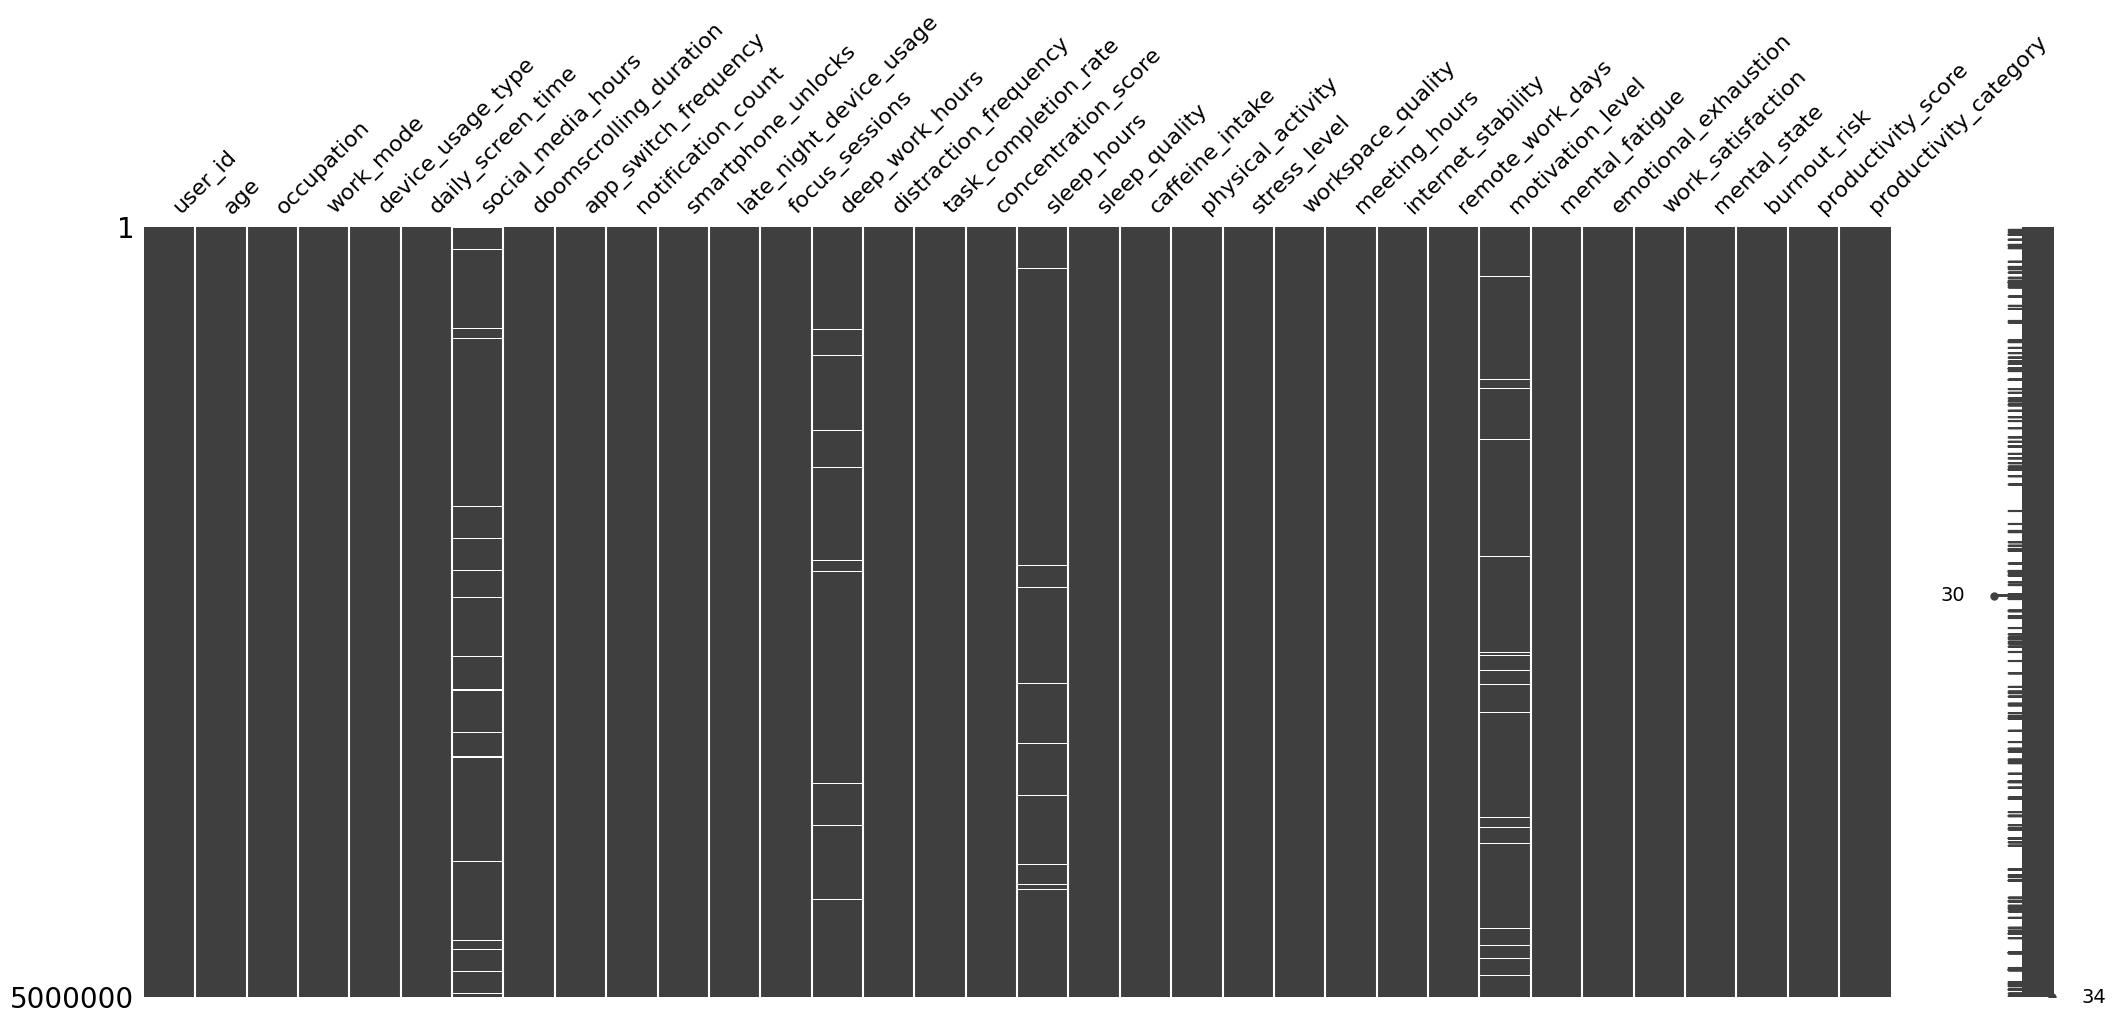

In [30]:
msno.matrix(df.to_pandas())